# Observation Gap Summary

Reads the canonical DTL logs from
`logs/sim2real_observations/cityflow_{agent}/{network}/baseline_v1_*/logger/`.

**Run layout.** `direct_transfer` has one run dir per setting
(`baseline_v1_direct_transfer_{setting}_s0`, single zero-shot `REAL_TEST` row). The six train-once
methods (`domain_randomization` and the latent-observation family `vae` / `recon_baseline` / `darla` /
`atc` / `lusr`) train one model per network and replay-evaluate it under all 16 observation settings
(`--replay_curve`), so one run dir holds 16 per-setting DTLs; the setting is parsed from the first
`exp_name` token after the network prefix.

**Selection rule.** `direct_transfer` uses its single `REAL_TEST` row; every other method takes the
top-`TOP_REWARD_K` `REAL_TEST` replay-curve rows by reward and averages them.

**Gap** = selected real travel time − pretrained-tsc CityFlow ATT
(`logs/engine_baselines/{agent}/{network}/cityflow_direct_transfer`, `FINAL_TEST` row). ATT is the
headline; the CSV also carries queue/delay/throughput gaps against the same row (reward excluded;
for throughput negative is worse).

This notebook now also covers the latent-observation methods, superseding
`analyze_latent_observations.ipynb` (which still reads the old log layout).

**Note.** Parsing, selection and the CSV export live in `scripts/gap_tables.py` (shared with `make_figures.ipynb`); this notebook is the exploratory companion — availability, pivot tables, bar charts and per-checkpoint traces.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# All parsing + selection logic lives in scripts/gap_tables.py (shared with
# make_figures.ipynb): newest usable DTL per cell, REAL_TEST rows (REAL_TRAIN
# fallback), cadence subsample, top-5 by reward with a stable mergesort +
# episode tie-break. build() parses logs/ -> tables/observation_table.csv and
# returns the raw (unformatted) per-cell frame used below.
from scripts.gap_tables import AGENTS, OBSERVATIONS as TASK

results_df = TASK.build(verbose=True)

NETWORK_ORDER = TASK.networks
SETTING_ORDER = TASK.settings
METHOD_ORDER = TASK.methods
SINGLE_SHOT_METHODS = TASK.single_shot
candidate_dtls, real_rows, read_dtl = TASK.candidate_dtls, TASK.real_rows, TASK.read_dtl

# fixed method -> color (Tol bright, CVD-safe); consistent across every figure
METHOD_COLORS = {
    'direct_transfer': '#4477AA',
    'domain_randomization': '#EE6677',
    'vae': '#228833',
    'recon_baseline': '#CCBB44',
    'darla': '#66CCEE',
    'atc': '#AA3377',
    'lusr': '#BBBBBB',
}


## Method Availability

In [4]:
availability = (
    results_df.pivot_table(index=['agent', 'network'], columns='method',
                           values='travel_time', aggfunc='count', observed=False)
    .reindex(columns=METHOD_ORDER)
    .fillna(0).astype(int)
)
availability  # number of settings with a usable run, per method

method                  direct_transfer  domain_randomization  vae  \
agent      network                                                   
dqn        tempe_1x1                 16                    16   16   
           bullhead_1                16                    16   16   
           cologne1                  16                    16   16   
           ingolstadt1               16                    16   16   
           hz1x1                     16                    16   16   
           tempe_16                  16                    16   16   
           bullhead_3                16                    16   16   
           cologne3                  16                    16   16   
           ingolstadt7               16                    16   16   
           hz4x4                     16                    16   16   
presslight tempe_1x1                 16                    16   16   
           bullhead_1                16                    16   16   
           cologne1                  16                    16   16   
           ingolstadt1               16                    16   16   
           hz1x1                     16                    16   16   
           tempe_16                  16                    16   16   
           bullhead_3                16                    16   16   
           cologne3                  16                    16   16   
           ingolstadt7               16                    16   16   
           hz4x4                     16                    16   16   

method                  recon_baseline  darla  atc  lusr  
agent      network                                        
dqn        tempe_1x1                16     16   16    16  
           bullhead_1               16     16   16    16  
           cologne1                 16     16   16    16  
           ingolstadt1              16     16   16    16  
           hz1x1                    16     16   16    16  
           tempe_16                 16     16   16    16  
           bullhead_3               16     16   16    16  
           cologne3                 16     16   16    16  
           ingolstadt7              16     16   16    16  
           hz4x4                    16     16   16    16  
presslight tempe_1x1                16     16   16    16  
           bullhead_1               16     16   16    16  
           cologne1                 16     16   16    16  
           ingolstadt1              16     16   16    16  
           hz1x1                    16     16   16    16  
           tempe_16                 16     16   16    16  
           bullhead_3               16     16   16    16  
           cologne3                 16     16   16    16  
           ingolstadt7              16     16   16    16  
           hz4x4                    16     16   16    16

## Real Travel-Time Tables (selected real rows)

In [5]:
att_tables = {
    agent: (
        results_df[results_df['agent'] == agent]
        .pivot_table(index=['network', 'setting'], columns='method', values='travel_time', observed=False)
        .reindex(columns=METHOD_ORDER)
        .round(1)
    )
    for agent in AGENTS
}
att_tables['dqn']

method              direct_transfer  domain_randomization     vae  \
network   setting                                                   
tempe_1x1 noise3              157.2                 167.1   157.8   
          noise5              162.8                 164.8   158.6   
          noise10             179.0                 169.0   159.4   
          noise20             227.3                 183.9   163.2   
          dz10                900.0                 160.4   330.7   
...                             ...                   ...     ...   
hz4x4     sensor70            983.4                1413.7  1778.6   
          combine1            625.2                 722.3   540.7   
          combine2            625.7                 773.1   590.3   
          combine3            853.8                 812.4   992.6   
          combine4            861.5                 714.1   948.2   

method              recon_baseline   darla     atc    lusr  
network   setting                                           
tempe_1x1 noise3             158.0   167.7   160.8   155.9  
          noise5             157.5   172.7   160.4   156.8  
          noise10            158.3   183.4   161.1   160.0  
          noise20            160.4   220.1   167.8   165.6  
          dz10               307.0   154.5   275.6   159.9  
...                            ...     ...     ...     ...  
hz4x4     sensor70          1475.2  1568.6  1303.1  1424.1  
          combine1           539.1   580.4   518.6   604.6  
          combine2           602.7   676.8   563.8   759.6  
          combine3           667.6   748.9   657.5  1023.2  
          combine4           805.3   798.2   596.9   919.4  

[160 rows x 7 columns]

In [6]:
att_tables['presslight']

method              direct_transfer  domain_randomization     vae  \
network   setting                                                   
tempe_1x1 noise3              156.8                 162.6   170.3   
          noise5              159.0                 160.5   161.3   
          noise10             171.1                 159.7   159.6   
          noise20             190.7                 159.3   162.0   
          dz10                340.3                 152.0   479.9   
...                             ...                   ...     ...   
hz4x4     sensor70           1151.6                1155.5  1075.8   
          combine1            522.0                 455.5   567.3   
          combine2            509.4                 440.5   628.2   
          combine3            713.1                 437.2   665.2   
          combine4            742.4                 438.9   599.0   

method              recon_baseline   darla     atc    lusr  
network   setting                                           
tempe_1x1 noise3             161.2   234.3   169.8   217.6  
          noise5             159.5   210.8   167.7   217.5  
          noise10            162.3   189.5   164.5   194.8  
          noise20            164.8   209.0   178.8   172.3  
          dz10               366.5   642.4   455.1   350.1  
...                            ...     ...     ...     ...  
hz4x4     sensor70           926.2  1078.5  1032.2  1161.0  
          combine1           604.6   668.0   674.9   863.2  
          combine2           594.5   709.4   656.3   888.5  
          combine3           677.4   717.0   696.6   973.0  
          combine4           581.3   677.5   671.4   792.7  

[160 rows x 7 columns]

## Gap vs CityFlow Baseline — `gap = real ATT − pretrained cityflow ATT`

In [7]:
gap_tables = {}
for agent in AGENTS:
    sub = results_df[results_df['agent'] == agent]
    table = (
        sub.pivot_table(index=['network', 'setting'], columns='method', values='gap_vs_cityflow', observed=False)
        .reindex(columns=METHOD_ORDER)
    )
    table.insert(0, 'cityflow_att', sub.groupby(['network', 'setting'], observed=False)['cityflow_att'].first())
    gap_tables[agent] = table.round(1)
gap_tables['dqn']

method              cityflow_att  direct_transfer  domain_randomization  \
network   setting                                                         
tempe_1x1 noise3           143.0             14.2                  24.1   
          noise5           143.0             19.8                  21.8   
          noise10          143.0             36.0                  26.0   
          noise20          143.0             84.3                  40.9   
          dz10             143.0            757.0                  17.4   
...                          ...              ...                   ...   
hz4x4     sensor70         355.1            628.3                1058.6   
          combine1         355.1            270.1                 367.2   
          combine2         355.1            270.6                 418.0   
          combine3         355.1            498.7                 457.3   
          combine4         355.1            506.4                 359.0   

method                 vae  recon_baseline   darla    atc    lusr  
network   setting                                                  
tempe_1x1 noise3      14.8            15.0    24.7   17.8    12.9  
          noise5      15.6            14.5    29.7   17.4    13.8  
          noise10     16.4            15.3    40.4   18.1    17.0  
          noise20     20.2            17.4    77.1   24.8    22.6  
          dz10       187.7           164.0    11.5  132.6    16.9  
...                    ...             ...     ...    ...     ...  
hz4x4     sensor70  1423.5          1120.1  1213.5  948.0  1069.0  
          combine1   185.6           184.0   225.3  163.5   249.5  
          combine2   235.2           247.6   321.7  208.7   404.5  
          combine3   637.5           312.5   393.8  302.4   668.1  
          combine4   593.1           450.2   443.1  241.8   564.3  

[160 rows x 8 columns]

In [8]:
gap_tables['presslight']

method              cityflow_att  direct_transfer  domain_randomization  \
network   setting                                                         
tempe_1x1 noise3           143.1             13.7                  19.5   
          noise5           143.1             15.9                  17.4   
          noise10          143.1             28.0                  16.6   
          noise20          143.1             47.6                  16.2   
          dz10             143.1            197.2                   8.9   
...                          ...              ...                   ...   
hz4x4     sensor70         349.2            802.4                 806.3   
          combine1         349.2            172.8                 106.3   
          combine2         349.2            160.2                  91.3   
          combine3         349.2            363.9                  88.0   
          combine4         349.2            393.2                  89.7   

method                vae  recon_baseline  darla    atc   lusr  
network   setting                                               
tempe_1x1 noise3     27.2            18.1   91.2   26.7   74.5  
          noise5     18.2            16.4   67.7   24.6   74.4  
          noise10    16.5            19.2   46.4   21.4   51.7  
          noise20    18.9            21.7   65.9   35.7   29.2  
          dz10      336.8           223.4  499.3  312.0  207.0  
...                   ...             ...    ...    ...    ...  
hz4x4     sensor70  726.6           577.0  729.3  683.0  811.8  
          combine1  218.1           255.4  318.8  325.7  514.0  
          combine2  279.0           245.3  360.2  307.1  539.3  
          combine3  316.0           328.2  367.8  347.4  623.8  
          combine4  249.8           232.1  328.3  322.2  443.5  

[160 rows x 8 columns]

## Gap Bar Chart

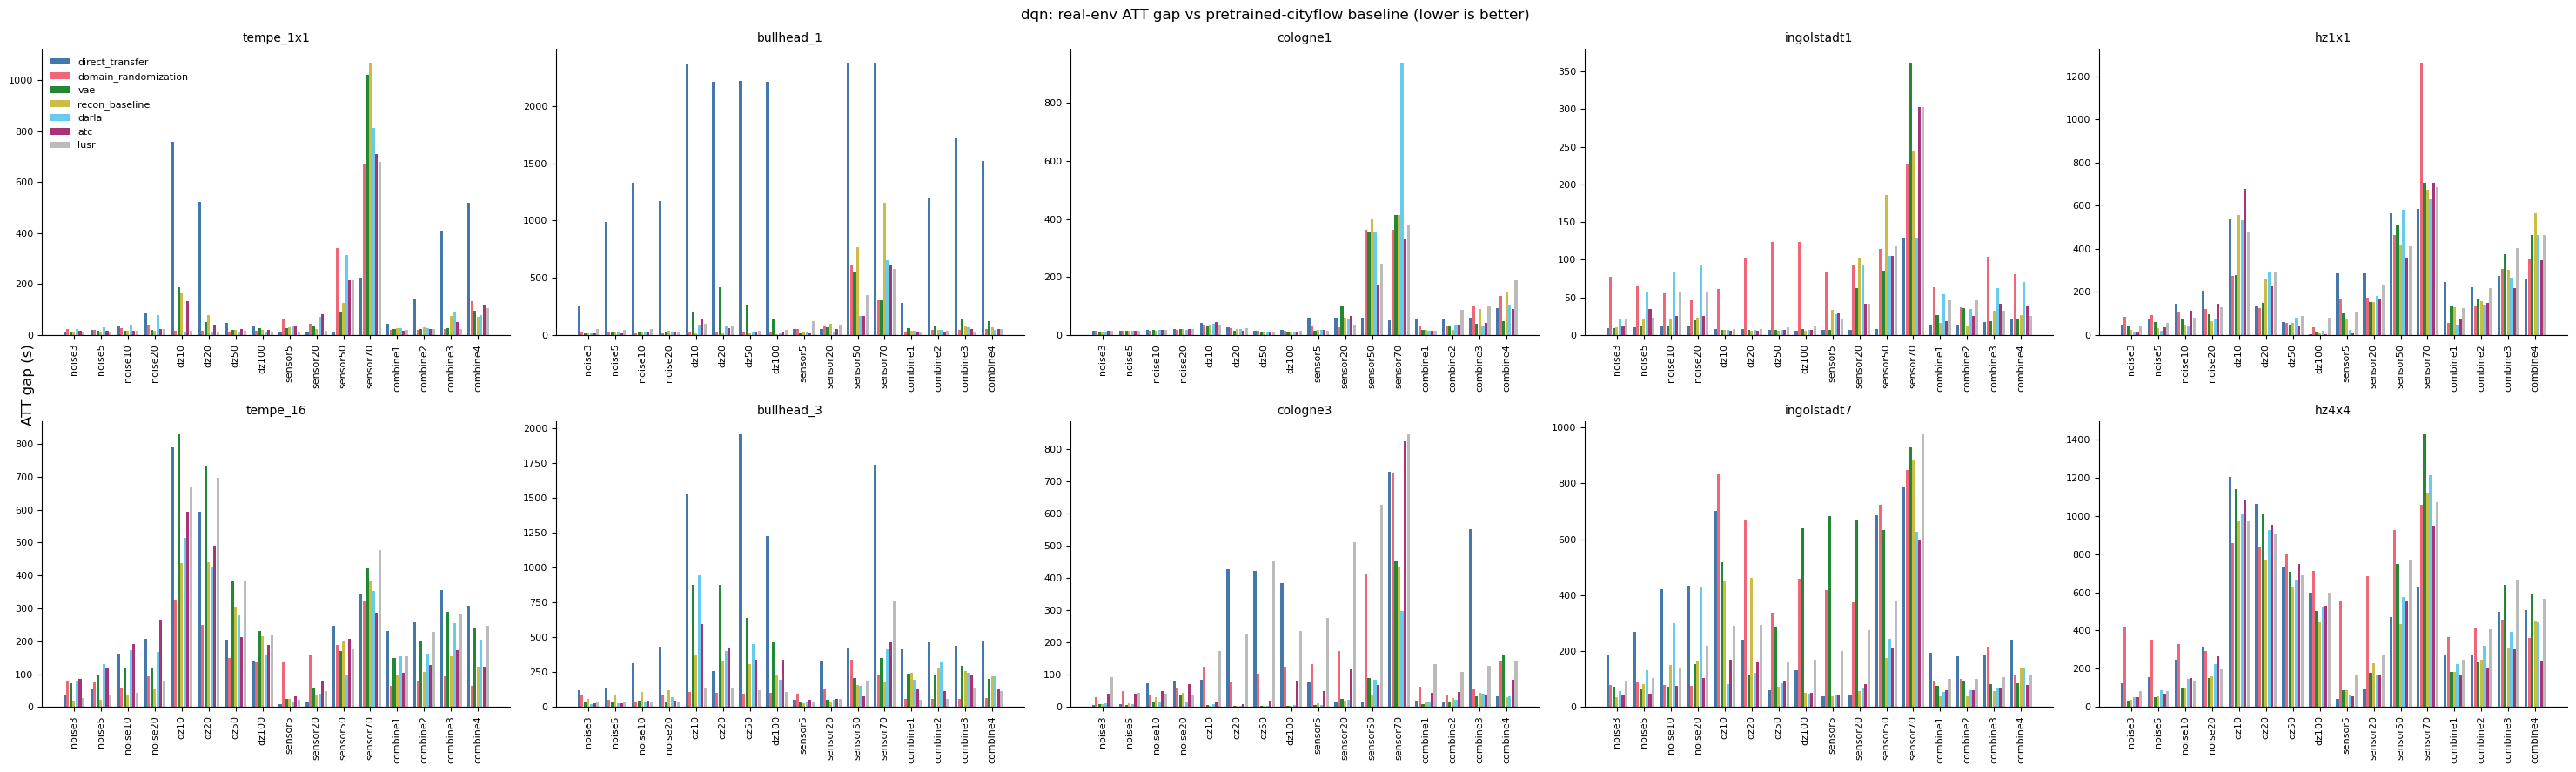

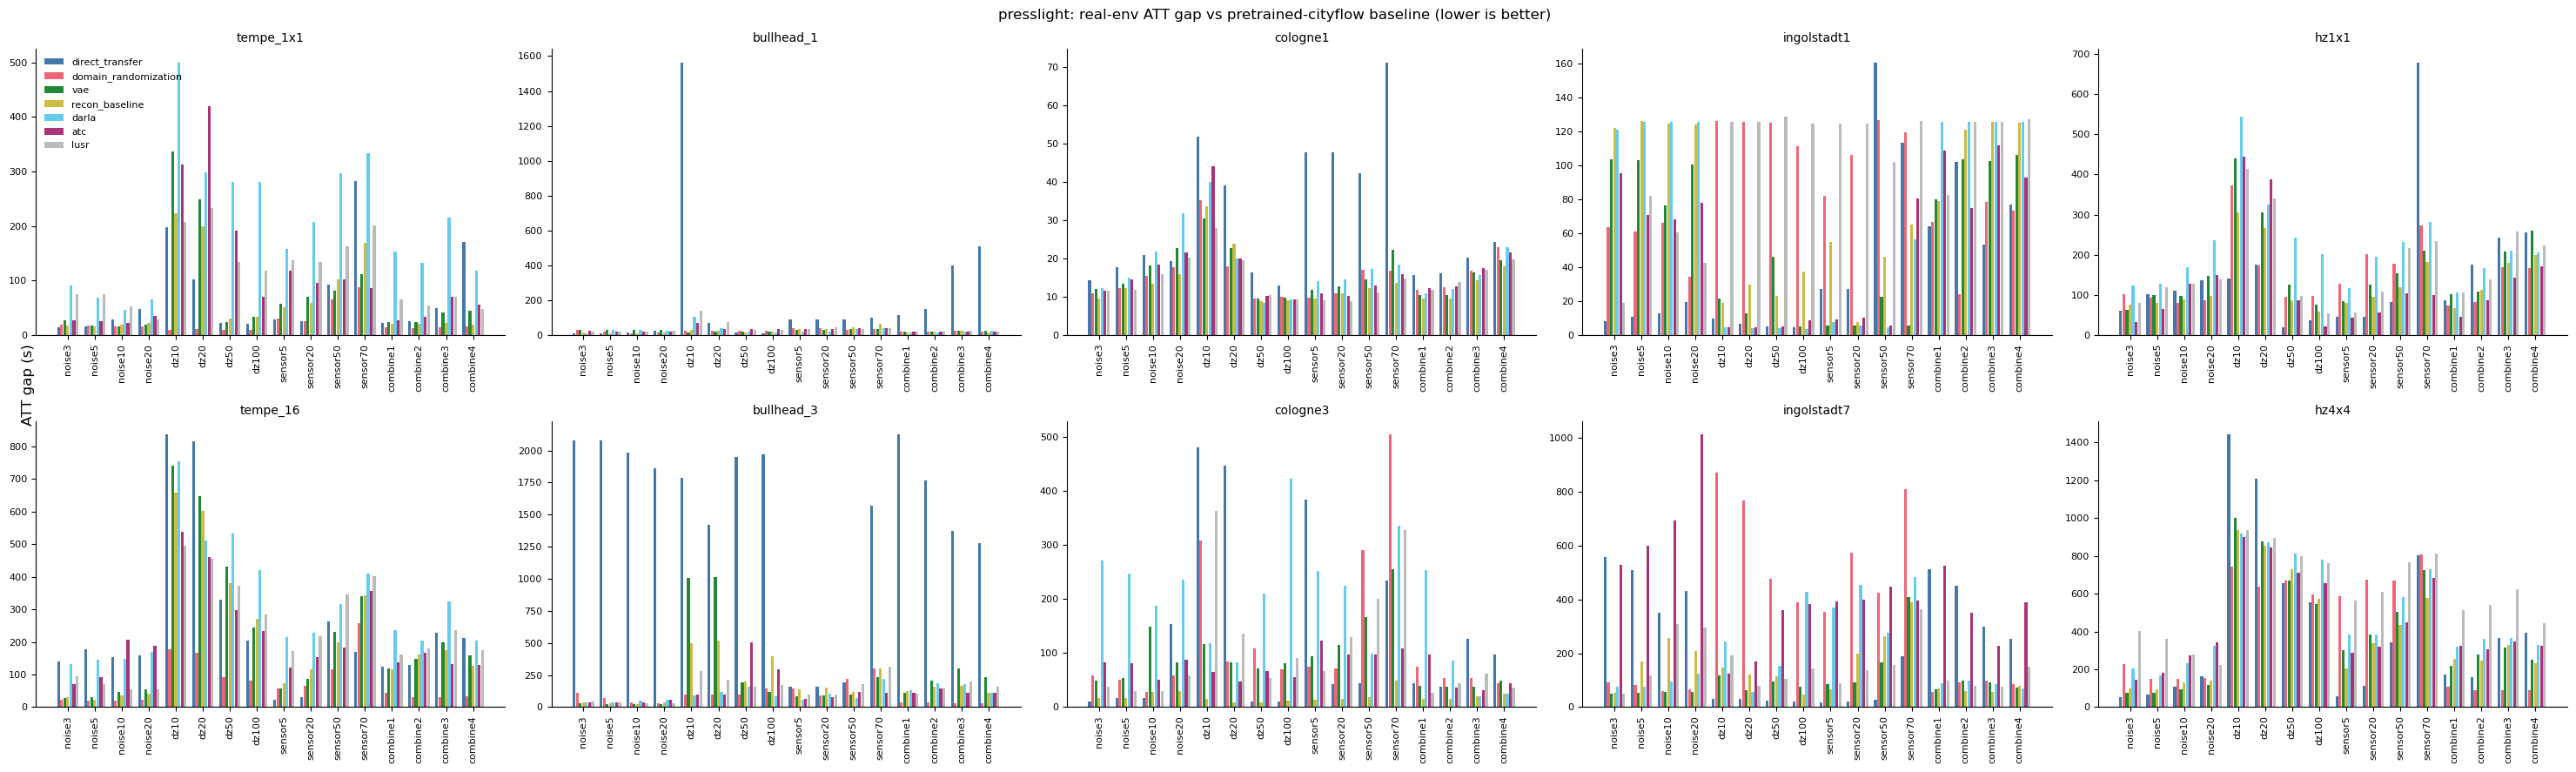

In [9]:
import matplotlib.pyplot as plt


def plot_gap_bars(agent, df, networks, methods, settings, xticklabels, figsize=(30, 9)):
    sub = df[df['agent'] == agent]
    fig, axes = plt.subplots(2, 5, figsize=figsize, squeeze=False)
    x = np.arange(len(settings))
    width = 0.8 / len(methods)
    for ax, network in zip(axes.flat, networks):
        net_df = sub[sub['network'] == network]
        for i, method in enumerate(methods):
            vals = [
                net_df[(net_df['setting'] == s) & (net_df['method'] == method)]['gap_vs_cityflow'].mean()
                for s in settings
            ]
            ax.bar(x + (i - (len(methods) - 1) / 2) * width, vals, width * 0.9,
                   color=METHOD_COLORS[method], label=method)
        ax.axhline(0, color='0.4', linewidth=0.8)
        ax.set_title(str(network), fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(xticklabels, fontsize=7, rotation=90)
        ax.tick_params(labelsize=8)
        ax.spines[['top', 'right']].set_visible(False)
    for ax in axes.flat[len(networks):]:
        ax.set_visible(False)
    axes.flat[0].legend(loc='upper left', fontsize=8, frameon=False)
    fig.suptitle(f'{agent}: real-env ATT gap vs pretrained-cityflow baseline (lower is better)')
    fig.supylabel('ATT gap (s)')
    fig.tight_layout()
    plt.show()


for agent in AGENTS:
    plot_gap_bars(agent, results_df, NETWORK_ORDER, METHOD_ORDER, SETTING_ORDER, SETTING_ORDER)

## Real-Eval Travel-Time Traces

Replay curves for the train-once methods; limited to two representative networks — edit `TRACE_NETWORKS` for more.

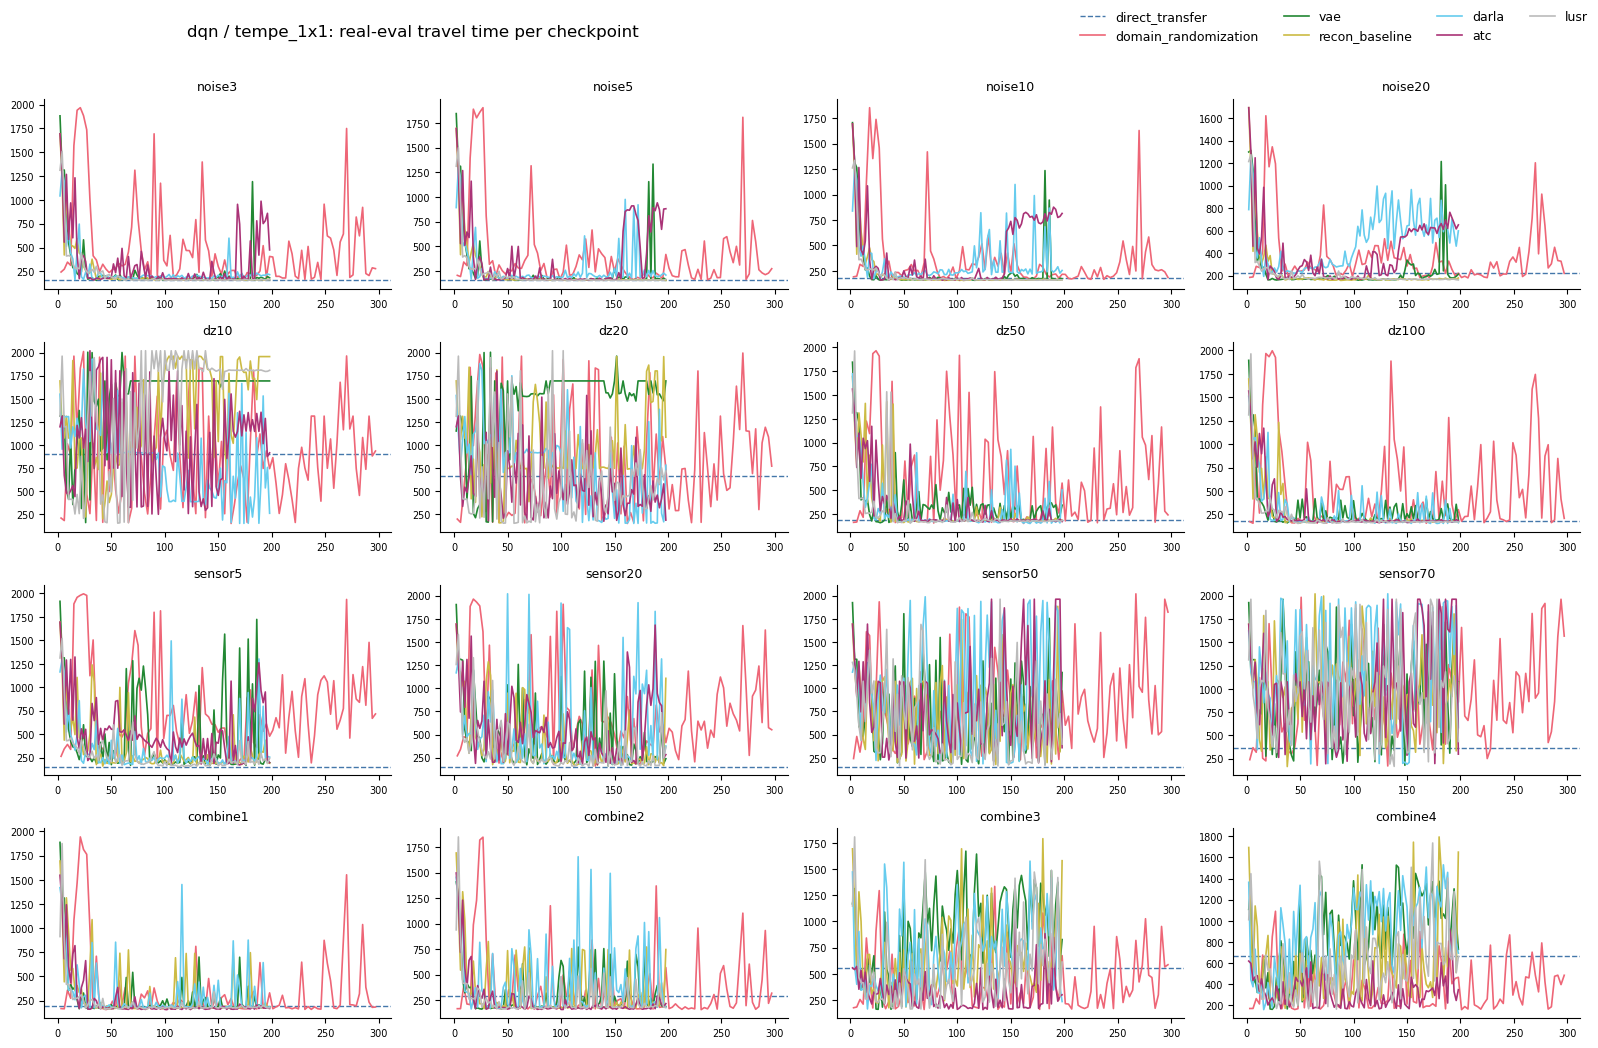

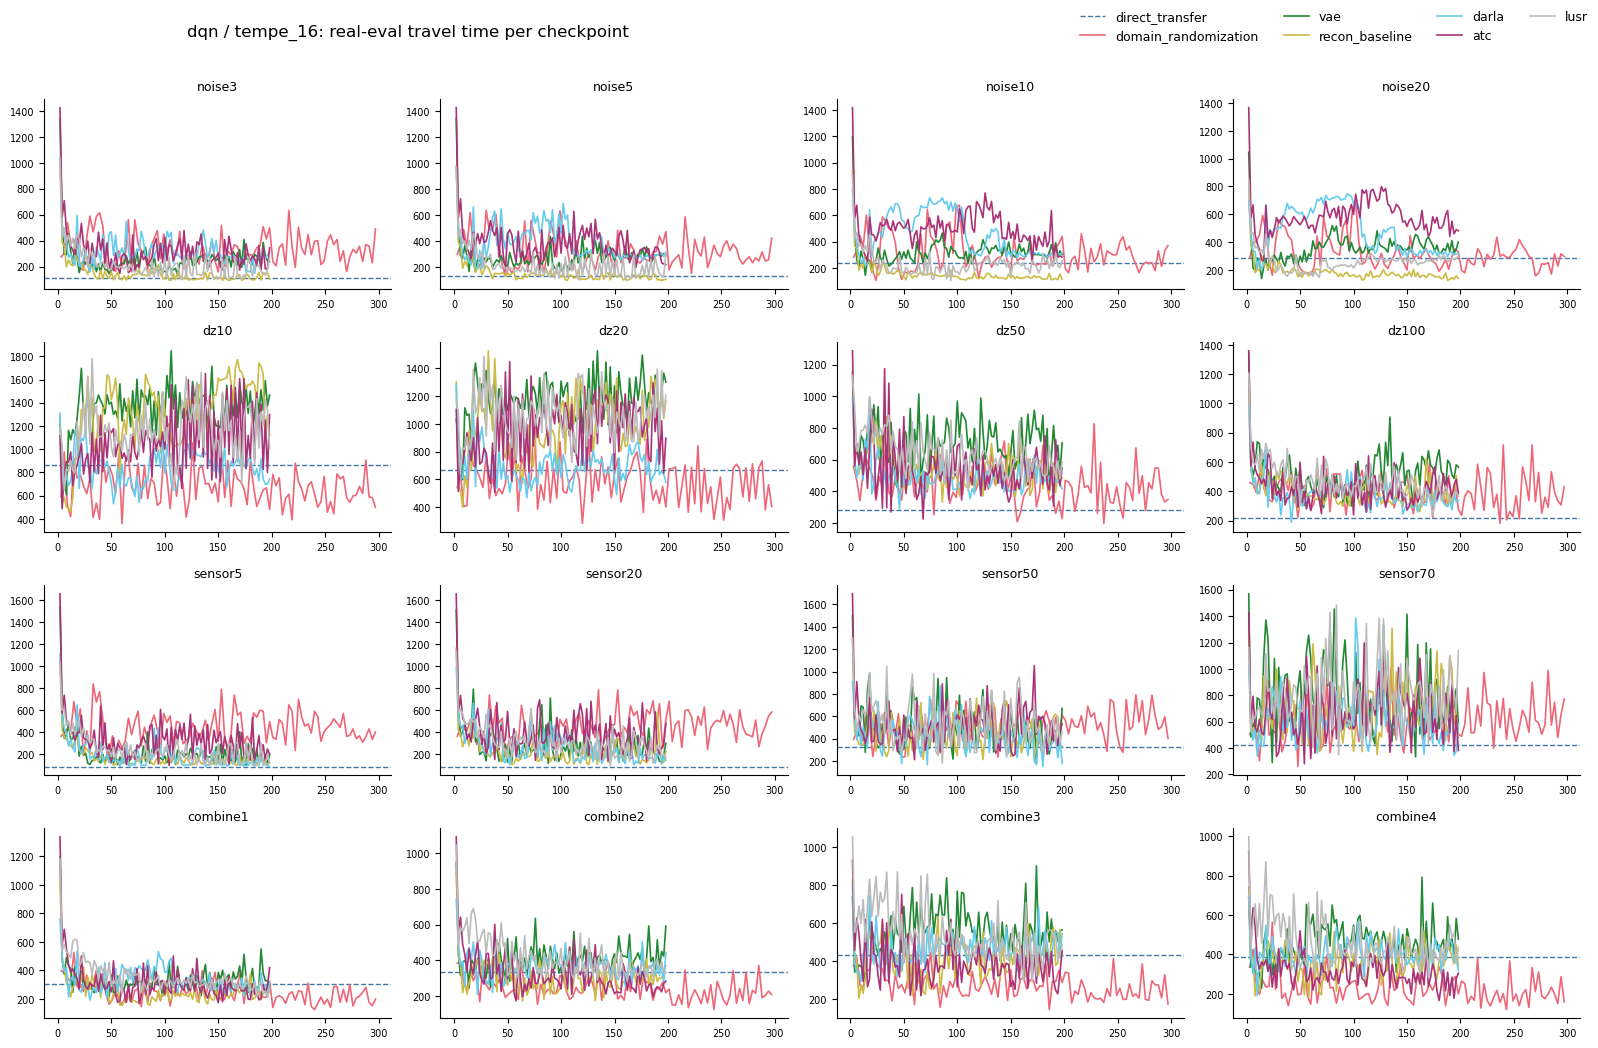

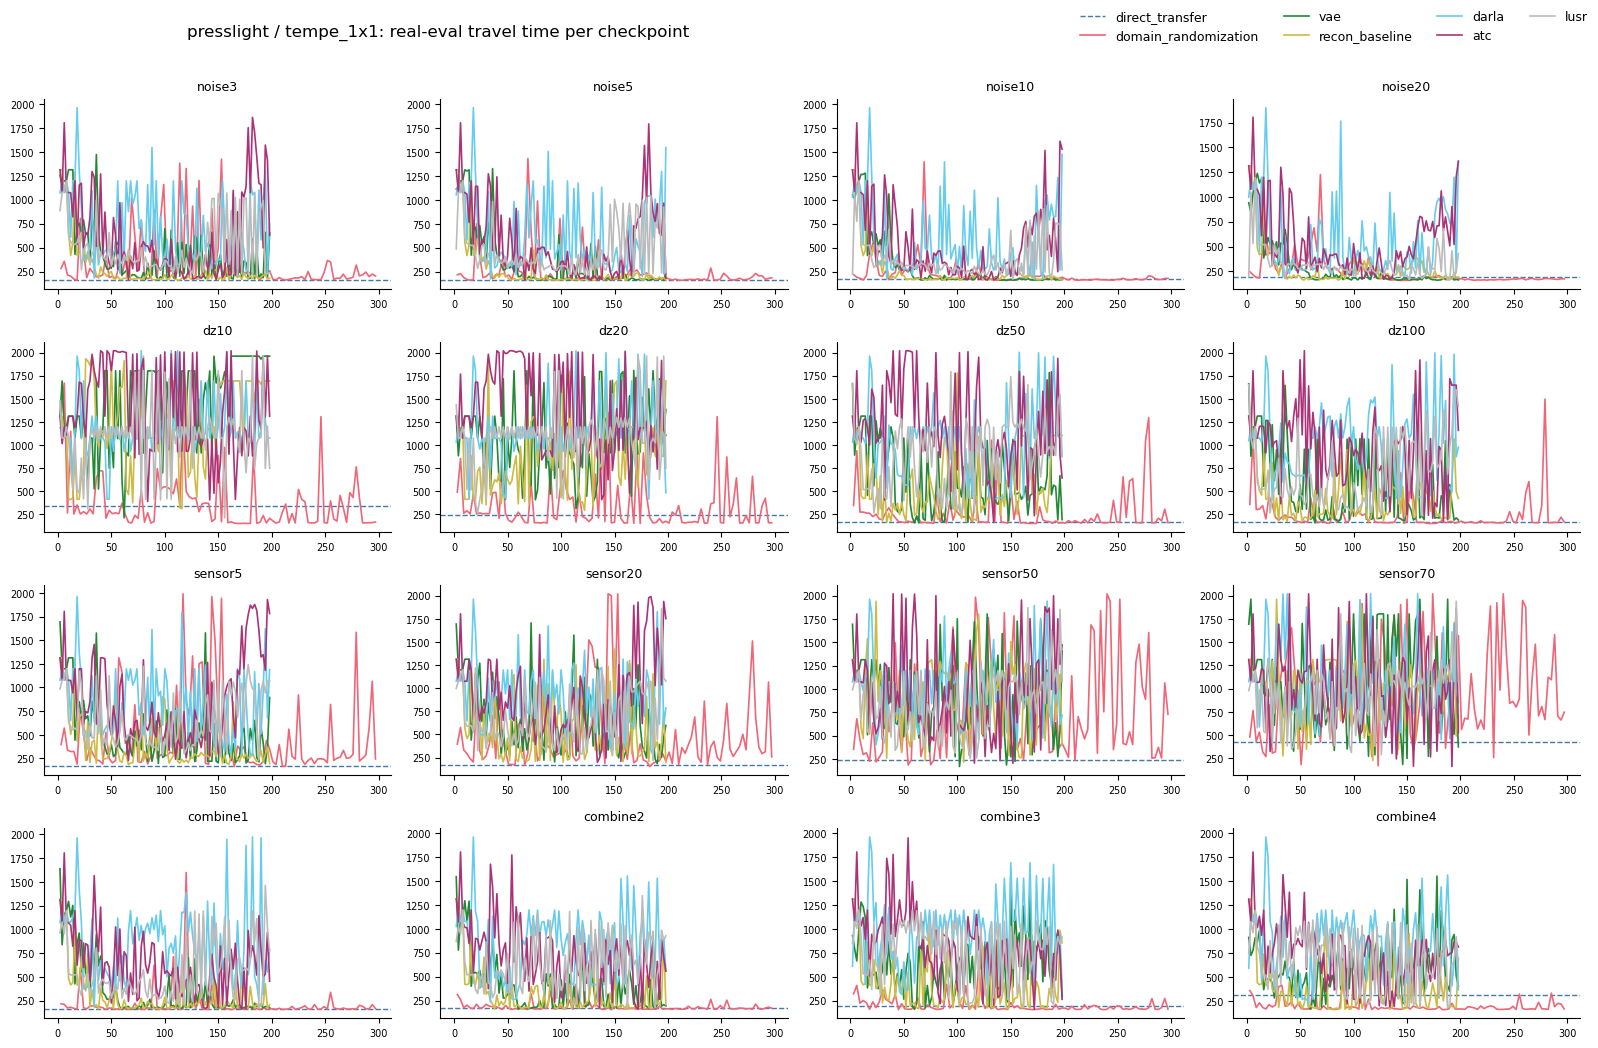

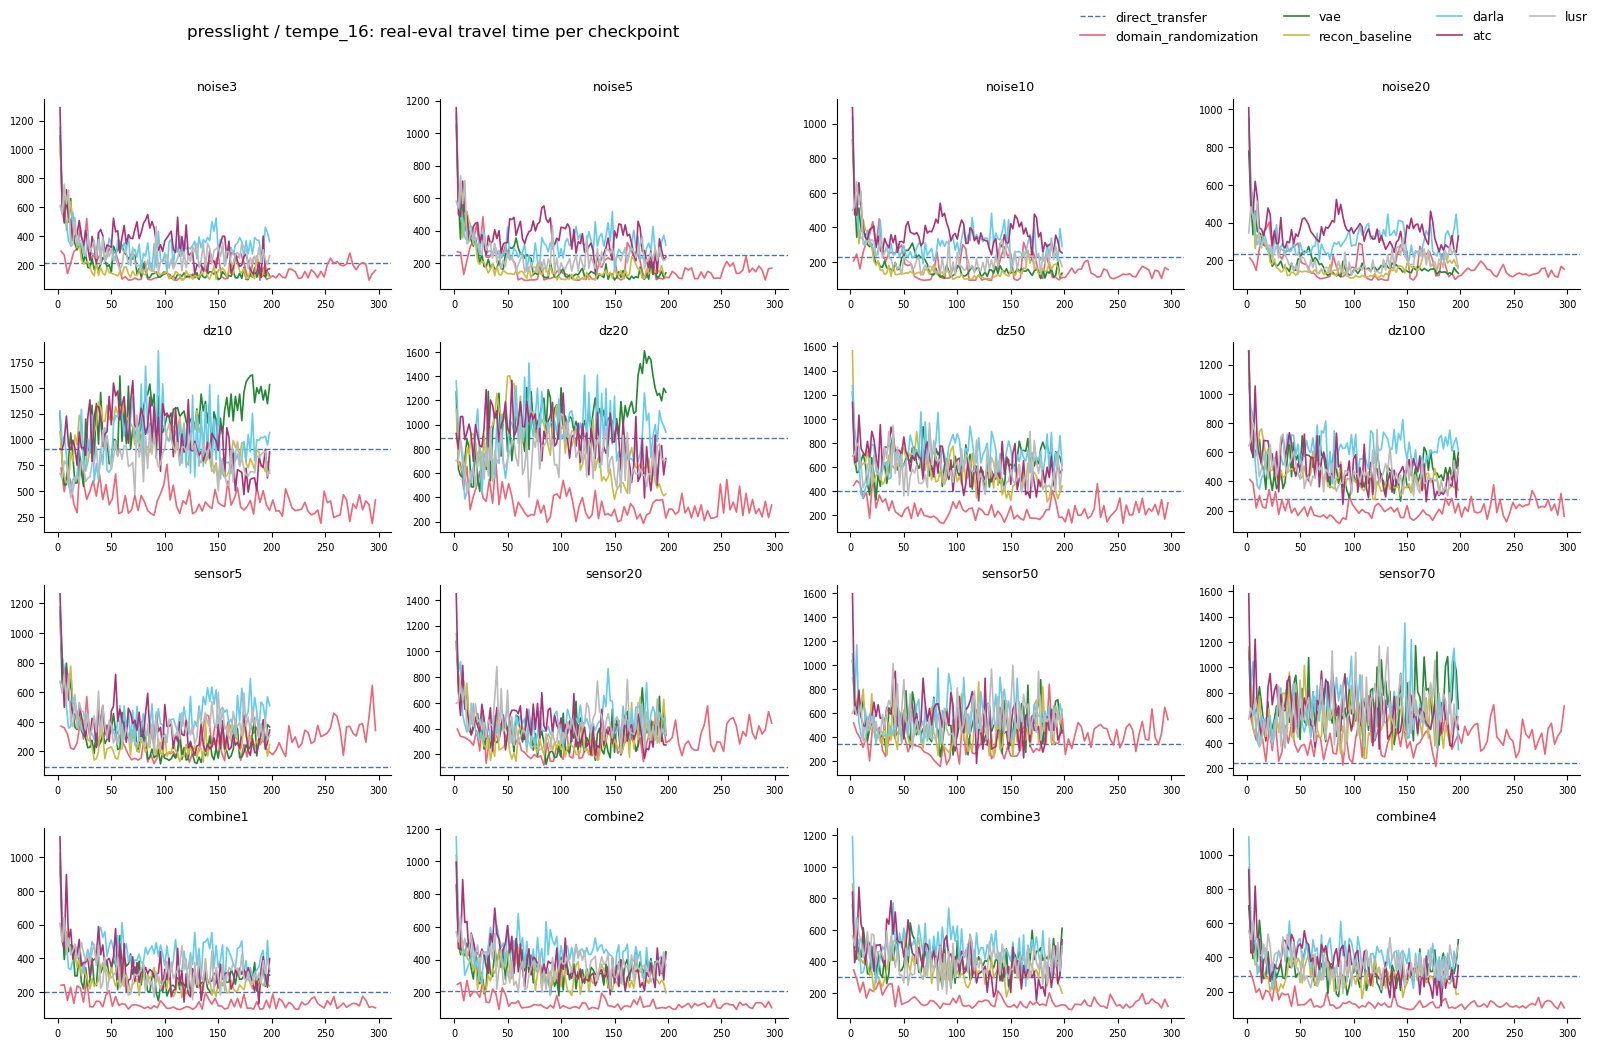

In [11]:
# Replay curves for the train-once methods; direct_transfer (single zero-shot row)
# is drawn as a dashed reference line. 4x4 grid = the 16 observation settings.
TRACE_NETWORKS = ['tempe_1x1', 'tempe_16']


def real_trace(agent, network, method, setting):
    for log_path in reversed(candidate_dtls(agent, network, method, setting)):
        rows = real_rows(read_dtl(log_path))
        if len(rows) >= 2:
            return rows.sort_values('episode')
    return None


for agent in AGENTS:
    for network in TRACE_NETWORKS:
        fig, axes = plt.subplots(4, 4, figsize=(16, 10.5), squeeze=False)
        for ax, setting in zip(axes.flat, SETTING_ORDER):
            for method in METHOD_ORDER:
                if method in SINGLE_SHOT_METHODS:
                    dt = results_df[(results_df['agent'] == agent) & (results_df['network'] == network)
                                    & (results_df['setting'] == setting) & (results_df['method'] == method)]
                    if len(dt):
                        ax.axhline(float(dt['travel_time'].iloc[0]), color=METHOD_COLORS[method],
                                   linestyle='--', linewidth=1.0, label=method)
                    continue
                rows = real_trace(agent, network, method, setting)
                if rows is None:
                    continue
                ax.plot(rows['episode'], rows['travel_time'], color=METHOD_COLORS[method],
                        linewidth=1.2, label=method)
            ax.set_title(setting, fontsize=9)
            ax.tick_params(labelsize=7)
            ax.spines[['top', 'right']].set_visible(False)
        handles, labels = axes[0][0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', fontsize=9, frameon=False, ncols=4)
        fig.suptitle(f'{agent} / {network}: real-eval travel time per checkpoint', x=0.12, ha='left')
        fig.tight_layout(rect=(0, 0, 1, 0.97))
        plt.show()